In [141]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [142]:
words=open(r'C:\Users\arput\OneDrive\Documents\Learning_ML\project\ML_Simple_project\Bi_Gram_Model\names.txt').read()
stoi={}
itos={}
word=words.splitlines()
w=words.replace('\n','.')
w=list(set(w))
w.sort()
print(len(w))
for i in range(0,len(w)):
    stoi[w[i]]=i
    itos[i]=w[i]



27


In [143]:
xs=[]
ys=[]
words=open(r'C:\Users\arput\OneDrive\Documents\Learning_ML\project\ML_Simple_project\Bi_Gram_Model\names.txt').read()
for i in word:
    name="."+i+"."
    for l,m in zip(name,name[1:]):
        xs.append(stoi[l])
        ys.append(stoi[m])


In [144]:
w1=np.random.uniform(-1,1,size=(27,27))
def backwardpass():
    dloss = np.ones_like(loss) / len(softmax)
    dprob = -(1 / prob) * dloss
    dsoftmax = np.zeros_like(softmax)
    dsoftmax[np.arange(len(ys)), ys] = dprob
    S = np.sum(ex, axis=1, keepdims=True)
    dex = (
        dsoftmax / S
        - np.sum(dsoftmax * ex, axis=1, keepdims=True) / S**2
    )
    dlogits = np.exp(logits) * dex
    dw1 = np.zeros_like(w1)
    for i in range(len(xs)):
        dw1[xs[i]] += dlogits[i]
    dlogits_simple = softmax.copy()
    dlogits_simple[np.arange(len(ys)), ys] -= 1
    dlogits_simple /= len(ys)

    print(
        np.max(
            np.abs(dlogits - dlogits_simple)
        )
    )
    print(dlogits)
    print(dlogits_simple)
    return dw1

In [145]:
step=[]
lossl=[]

In [153]:
for i in range(1000):
    logits=w1[xs]
    ex=np.exp(logits)
    softmax=ex/np.sum(ex,axis=1,keepdims=True)
    loss=0
    prob = softmax[np.arange(len(ys)), ys]
    loss=-np.log(prob)
    floss=np.sum(loss)/len(softmax)
    lossl.append(floss)
    dw1=backwardpass()
    print(floss)
    lr = 1
    w1 -= lr * dw1



1.6940658945086007e-21
[[ 1.24601281e-08  6.02201578e-07  1.77324726e-07 ...  2.29013205e-08
   7.11817131e-08  1.25625943e-07]
 [ 8.51076051e-07  1.39311928e-07  2.74656564e-08 ...  3.03247810e-08
   2.25104096e-07  3.95898220e-08]
 [ 2.88998368e-07  1.67773135e-06  6.90221193e-08 ...  3.17704638e-08
   1.35039120e-07  2.52491472e-08]
 ...
 [ 8.89105259e-07  9.50140283e-07  3.60431963e-08 ...  2.78524157e-08
   2.45125780e-08 -4.34749093e-06]
 [ 1.80682862e-07  1.48583950e-06  1.03991702e-07 ... -4.32586138e-06
   1.49659514e-07  7.76113640e-08]
 [-4.01334667e-06  5.41457016e-07  8.41118460e-08 ...  2.22343861e-07
   7.12006378e-08  6.96167632e-08]]
[[ 1.24601281e-08  6.02201578e-07  1.77324726e-07 ...  2.29013205e-08
   7.11817131e-08  1.25625943e-07]
 [ 8.51076051e-07  1.39311928e-07  2.74656564e-08 ...  3.03247810e-08
   2.25104096e-07  3.95898220e-08]
 [ 2.88998368e-07  1.67773135e-06  6.90221193e-08 ...  3.17704638e-08
   1.35039120e-07  2.52491472e-08]
 ...
 [ 8.89105259e-07  9.

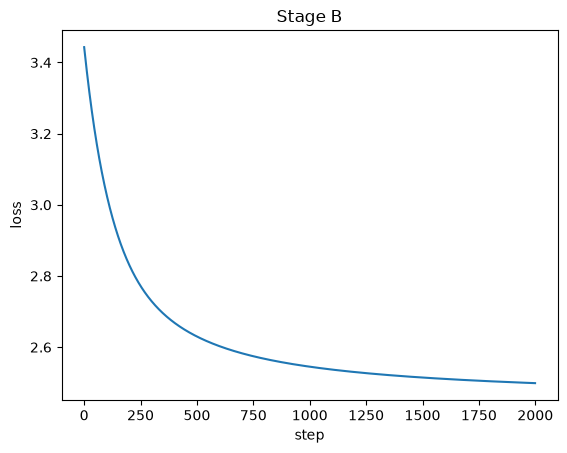

In [152]:
plt.plot(lossl)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Stage B")
plt.show()

In [148]:
floss

np.float64(2.5452641443763557)

In [149]:
lossl[2500:]

[]

In [150]:
print("loss:", floss)
print("mean |gradient|:", np.mean(np.abs(dw1)))
print("max |gradient|:", np.max(np.abs(dw1)))

loss: 2.5452641443763557
mean |gradient|: 0.00026902482597996393
max |gradient|: 0.0014609855273106647
